# SafePredict-XAI: Feature Engineering (First 24 Hours)

**Project:** SafePredict-XAI  
**Phases:** (Cohort Construction)  (Feature Engineering)  
**Objective:** Transform longitudinal eICU clinical observations from the first 24 hours into a single, high-fidelity tabular feature dataset (**one row per ICU stay**) for machine learning mortality risk prediction.

---

### Core Principles & Architecture:
1. **Strict 24-Hour Landmark Horizon ($t = 1440$ min):** All observations are strictly bounded within $0 \le t \le 1440$ minutes after ICU admission.
2. **One Row Per ICU Stay:** Final modeling table contains exactly $N = 1,403$ unique index stays.
3. **No Target/Temporal Leakage:** Discharge offsets, discharge statuses, and post-24h data are strictly excluded from predictive features. Identifiers (`patientunitstayid`, `patienthealthsystemstayid`) and target (`hospital_mortality`) are isolated.
4. **Clinical vs Data Quality Separation:** Meta-level data quality indicators (`lab_measurement_count`, `vital_measurement_count`, `available_lab_count`, `available_vital_count`, `missing_feature_count`) are explicitly distinguishable from physiological predictors.
5. **Strict Stop:** No machine learning models are trained in this notebook.


## 1. Setup & Ingestion of Cleaned 24-Hour Cohort Tables

We import Polars, visualization libraries, and our production feature engineering pipeline from `src.features` and `src.data_pipeline`.


In [1]:
import sys
from pathlib import Path
import json
import polars as pl
import matplotlib.pyplot as plt
import numpy as np

# Styling configuration
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 10
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# Import modular pipeline
if Path("src").exists():
    sys.path.insert(0, ".")
elif Path("../src").exists():
    sys.path.insert(0, "..")

from src.features import (
    extract_patient_admission_features,
    extract_vital_features,
    extract_lab_features,
    compute_data_quality_features,
    build_model_dataset,
    validate_model_dataset,
    SELECTED_LABS,
    SELECTED_VITALS,
    ADMISSION_FEATURE_COLS,
    IDENTIFIER_COLS,
    TARGET_COL,
)

# Resolve directories
base_dir = Path("..") if Path("../data/processed").exists() else Path(".")
processed_dir = base_dir / "data" / "processed"
reports_dir = base_dir / "reports"

# Load Phase 3 processed cohort tables
patient_df = pl.read_parquet(processed_dir / "cohort_patient.parquet")
vitals_24h_df = pl.read_parquet(processed_dir / "cohort_vitals_24h.parquet")
labs_24h_df = pl.read_parquet(processed_dir / "cohort_labs_24h.parquet")

print("Cleaned 24-Hour Cohort Tables Loaded:")
print(f"  • cohort_patient.parquet:    {patient_df.height:,} stays x {patient_df.width} cols")
print(f"  • cohort_vitals_24h.parquet:  {vitals_24h_df.height:,} records x {vitals_24h_df.width} cols")
print(f"  • cohort_labs_24h.parquet:    {labs_24h_df.height:,} records x {labs_24h_df.width} cols")


Cleaned 24-Hour Cohort Tables Loaded:
  • cohort_patient.parquet:    1,403 stays x 32 cols
  • cohort_vitals_24h.parquet:  375,584 records x 19 cols
  • cohort_labs_24h.parquet:    65,866 records x 11 cols


## 2. Patient Admission Features

Admission-time variables are verified to be available at or before ICU admission:
- `age_numeric`: Continuous age (years, '> 89' mapped to 90.0)
- `age_gt89`: Binary indicator for elderly de-identification
- `gender`: Biological sex (Female, Male, Unknown)
- `ethnicity`: Patient ethnic background
- `admissionheight`: Stature (cm)
- `admissionweight`: Body weight (kg)
- `unittype`: Type of intensive care unit (Med-Surg, CCU, MICU, SICU, Neuro, Cardiac)
- `unitadmitsource`: Origin of ICU admission (Emergency Department, Floor, Operating Room, Direct Admit, Other)


In [2]:
base_df, admission_features = extract_patient_admission_features(patient_df)

print(f"Extracted {len(admission_features)} Admission Features:")
for col in admission_features:
    null_ct = base_df.filter(pl.col(col).is_null()).height
    print(f"  • {col:20s}: {base_df[col].dtype} | Missing: {null_ct:3d} ({null_ct/base_df.height*100:4.1f}%)")


Extracted 8 Admission Features:
  • age_numeric         : Float64 | Missing:   2 ( 0.1%)
  • age_gt89            : Int32 | Missing:   2 ( 0.1%)
  • gender              : String | Missing:   0 ( 0.0%)
  • ethnicity           : String | Missing:   0 ( 0.0%)
  • admissionheight     : Float64 | Missing:  25 ( 1.8%)
  • admissionweight     : Float64 | Missing:  24 ( 1.7%)
  • unittype            : String | Missing:   0 ( 0.0%)
  • unitadmitsource     : String | Missing:   0 ( 0.0%)


## 3. Vital Sign Features (0–24 Hours)

We aggregate 7 routine vital signs across the entire 24-hour observation window:
1. `heartrate` (bpm)
2. `sao2` (pulse oximetry %)
3. `respiration` (breaths/min)
4. `temperature` (°C)
5. `systemicsystolic` (arterial/cuff systolic BP mmHg)
6. `systemicdiastolic` (arterial/cuff diastolic BP mmHg)
7. `systemicmean` (mean arterial pressure MAP mmHg)

### Aggregations per Vital Sign:
- **`mean`:** Central tendency of physiological state
- **`min` & `max`:** Extreme excursions / acute instability
- **`std`:** Physiological volatility / hemodynamic variability
- **`count`:** Monitoring intensity / data quality indicator


In [3]:
vital_features_df, vital_clinical_features, vital_quality_features = extract_vital_features(
    vitals_24h_df, vital_cols=SELECTED_VITALS
)

print(f"Vital Feature Aggregations Extracted (N = {vital_features_df.height:,} stays):")
print(f"  • Clinical Vital Predictors: {len(vital_clinical_features)} features")
print(f"  • Vital Quality Indicators:  {len(vital_quality_features)} features")
print("\nSample Vital Feature Matrix:")
print(vital_features_df.select(['patientunitstayid', 'heartrate_mean', 'heartrate_min', 'heartrate_max', 'heartrate_std', 'heartrate_count', 'vital_measurement_count']).head(5))


Vital Feature Aggregations Extracted (N = 1,364 stays):
  • Clinical Vital Predictors: 28 features
  • Vital Quality Indicators:  8 features

Sample Vital Feature Matrix:
shape: (5, 7)
┌──────────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────────┐
│ patientunits ┆ heartrate_m ┆ heartrate_m ┆ heartrate_m ┆ heartrate_s ┆ heartrate_c ┆ vital_measu │
│ tayid        ┆ ean         ┆ in          ┆ ax          ┆ td          ┆ ount        ┆ rement_coun │
│ ---          ┆ ---         ┆ ---         ┆ ---         ┆ ---         ┆ ---         ┆ t           │
│ i64          ┆ f64         ┆ f64         ┆ f64         ┆ f64         ┆ u32         ┆ ---         │
│              ┆             ┆             ┆             ┆             ┆             ┆ u32         │
╞══════════════╪═════════════╪═════════════╪═════════════╪═════════════╪═════════════╪═════════════╡
│ 2462225      ┆ 98.927083   ┆ 76.0        ┆ 123.0       ┆ 12.247089   ┆ 288         ┆ 288         │
│ 14949

## 4. Laboratory Selection & 24-Hour Aggregations

Based on clinical relevance and empirical eICU availability from Phase 1/2, we select **15 prioritized lab tests**:
- **Renal & Electrolytes:** Creatinine, BUN, Sodium, Potassium, Chloride, Bicarbonate, Calcium, Magnesium
- **Metabolism:** Serum Glucose
- **Hematology:** Hemoglobin (Hgb), Hematocrit (Hct), WBC count, Platelet count
- **Tissue Perfusion & Acid-Base:** Lactate, Arterial/Venous pH

### Aggregations per Lab Test:
- **`first`:** Initial baseline upon ICU arrival
- **`last`:** Most recent state at the 24h landmark
- **`min` & `max`:** Extreme physiological bounds
- **`mean`:** 24h time-weighted mean level
- **`count`:** Test ordering frequency / clinical sampling intensity


In [4]:
lab_features_df, lab_clinical_features, lab_quality_features = extract_lab_features(
    labs_24h_df, selected_labs=SELECTED_LABS
)

print(f"Laboratory Aggregations Extracted (N = {lab_features_df.height:,} stays):")
print(f"  • Selected Labs:             {len(SELECTED_LABS)} clinical tests")
print(f"  • Clinical Lab Predictors:   {len(lab_clinical_features)} features (5 summaries x 15 labs)")
print(f"  • Lab Quality Indicators:     {len(lab_quality_features)} features (15 counts + total count)")
print("\nSample Lab Feature Matrix (Creatinine & Lactate):")
sample_lab_cols = [
    'patientunitstayid',
    'creatinine_first', 'creatinine_last', 'creatinine_max', 'creatinine_count',
    'lactate_first', 'lactate_last', 'lactate_max', 'lactate_count',
    'lab_measurement_count'
]
print(lab_features_df.select([c for c in sample_lab_cols if c in lab_features_df.columns]).head(5))


Laboratory Aggregations Extracted (N = 1,382 stays):
  • Selected Labs:             15 clinical tests
  • Clinical Lab Predictors:   75 features (5 summaries x 15 labs)
  • Lab Quality Indicators:     16 features (15 counts + total count)

Sample Lab Feature Matrix (Creatinine & Lactate):
shape: (5, 10)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ patientun ┆ creatinin ┆ creatinin ┆ creatinin ┆ … ┆ lactate_l ┆ lactate_m ┆ lactate_c ┆ lab_meas │
│ itstayid  ┆ e_first   ┆ e_last    ┆ e_max     ┆   ┆ ast       ┆ ax        ┆ ount      ┆ urement_ │
│ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ count    │
│ i64       ┆ f64       ┆ f64       ┆ f64       ┆   ┆ f64       ┆ f64       ┆ u32       ┆ ---      │
│           ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆ u32      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪

## 5. Engineered Data Quality Features

To facilitate algorithmic bias and data quality auditing without conflating quality indicators with clinical physiology, we create distinct metadata features:
1. `lab_measurement_count`: Total lab results recorded in 24h
2. `vital_measurement_count`: Total vital readings recorded in 24h
3. `available_lab_count`: Number of distinct selected lab types with $\ge 1$ reading (out of 15)
4. `available_vital_count`: Number of distinct vital signs with $\ge 1$ reading (out of 7)
5. `missing_feature_count`: Total missing clinical values across all physiological predictors
6. Individual per-variable counts (`heartrate_count`, `creatinine_count`, etc.)


In [5]:
# Run full build_model_dataset pipeline
model_df, feature_manifest = build_model_dataset(
    processed_dir=processed_dir,
    output_path=processed_dir / "model_data.parquet",
    reports_dir=reports_dir,
)

print("Master Feature Dataset Assembled:")
print(f"  • Total Rows:             {model_df.height:,} (Exactly 1 row per ICU stay)")
print(f"  • Total Columns:          {model_df.width}")
print(f"  • Clinical Features:      {len(feature_manifest['clinical_features'])}")
print(f"  • Data Quality Features:  {len(feature_manifest['quality_features'])}")
print(f"  • Identifiers (non-feat): {len(feature_manifest['identifiers'])}")
print(f"  • Target Label:           {feature_manifest['target']}")


Phase 4 Feature Engineering completed successfully!
  • Model Data Shape: (1403, 141) (1 row per ICU stay)
  • Clinical Features: 111 | Quality Features: 27
  • Saved Parquet: ..\data\processed\model_data.parquet
  • Saved Feature Catalog: ..\reports\metrics\feature_dictionary.json
Master Feature Dataset Assembled:
  • Total Rows:             1,403 (Exactly 1 row per ICU stay)
  • Total Columns:          141
  • Clinical Features:      111
  • Data Quality Features:  27
  • Identifiers (non-feat): 2
  • Target Label:           hospital_mortality


## 6. Comprehensive Validation & Anti-Leakage Audit

We verify all safety invariants:
1. **Cohort Shape:** Exactly $1,403$ rows $\times$ $1,403$ unique `patientunitstayid` keys.
2. **Target Balance:** `hospital_mortality` is binary with $122$ deaths ($8.70\%$) and $1,281$ survivors ($91.30\%$).
3. **No Target/Temporal Leakage:** Verified 0 discharge offsets, discharge statuses, or post-24h markers in features.


In [6]:
# Run automated validation suite
validation_report = validate_model_dataset(model_df, feature_manifest)

print("==================================================")
print("VALIDATION SUITE RESULTS")
print("==================================================")
print(f"  Status:                   {validation_report['status']}")
print(f"  One Row Per ICU Stay:     {validation_report['is_one_row_per_stay']} ({validation_report['total_rows']:,} rows)")
print(f"  Unique ICU Stays:         {validation_report['unique_stays']:,}")
print(f"  Target Classes:           {{0: {validation_report['target_balance']['alive_count']:,}, 1: {validation_report['target_balance']['expired_count']:,}}}")
print(f"  Mortality Prevalence:     {validation_report['target_balance']['mortality_prevalence_pct']:.2f}%")
print(f"  Leakage Columns Found:    {validation_report['leakage_columns_found']}")
print(f"  Total Extracted Features: {validation_report['total_features']}")
print("==================================================")


VALIDATION SUITE RESULTS
  Status:                   PASSED
  One Row Per ICU Stay:     True (1,403 rows)
  Unique ICU Stays:         1,403
  Target Classes:           {0: 1,281, 1: 122}
  Mortality Prevalence:     8.70%
  Leakage Columns Found:    0
  Total Extracted Features: 138


## 7. Feature Missingness & Data Quality Distribution

We visualize missingness across clinical features and inspect data quality distributions.


Top 15 Most Missing Clinical Features:
  • temperature_mean         : 1293 missing ( 92.2%)
  • temperature_min          : 1293 missing ( 92.2%)
  • temperature_max          : 1293 missing ( 92.2%)
  • temperature_std          : 1293 missing ( 92.2%)
  • systemicsystolic_std     : 1151 missing ( 82.0%)
  • systemicmean_std         : 1151 missing ( 82.0%)
  • systemicdiastolic_std    : 1150 missing ( 82.0%)
  • systemicdiastolic_mean   : 1149 missing ( 81.9%)
  • systemicdiastolic_min    : 1149 missing ( 81.9%)
  • systemicdiastolic_max    : 1149 missing ( 81.9%)
  • systemicsystolic_mean    : 1148 missing ( 81.8%)
  • systemicsystolic_min     : 1148 missing ( 81.8%)
  • systemicsystolic_max     : 1148 missing ( 81.8%)
  • systemicmean_mean        : 1148 missing ( 81.8%)
  • systemicmean_min         : 1148 missing ( 81.8%)


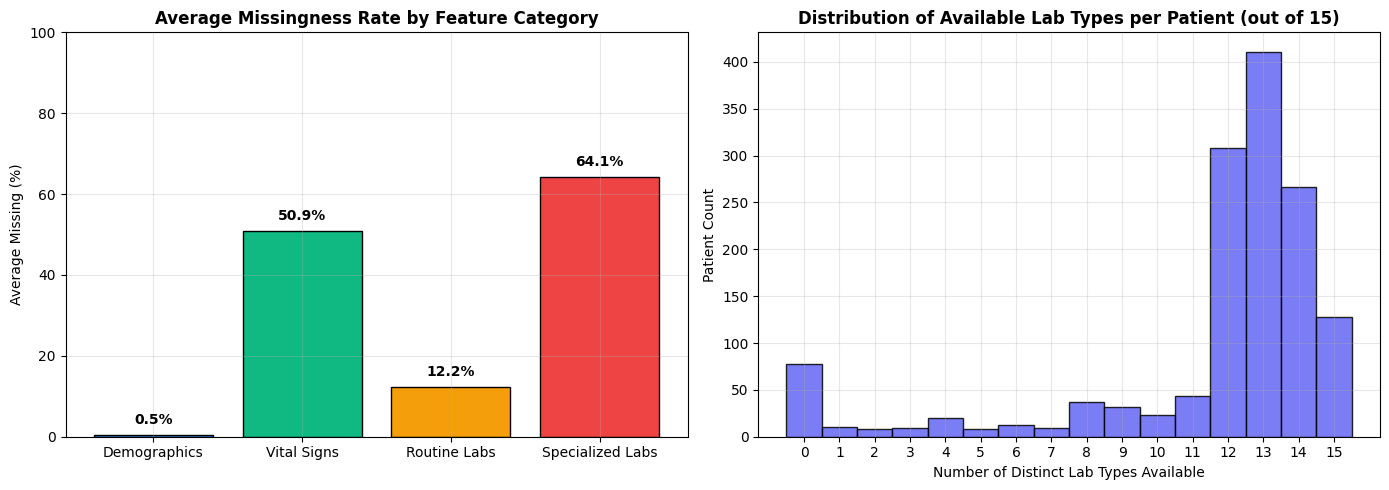

In [7]:
# Calculate missingness percentage across clinical features
missing_data = []
for col in feature_manifest["clinical_features"]:
    null_ct = model_df.filter(pl.col(col).is_null()).height
    null_pct = (null_ct / model_df.height) * 100
    missing_data.append((col, null_ct, null_pct))

missing_df = pl.DataFrame(
    missing_data,
    schema=["feature", "null_count", "null_pct"],
    orient="row"
).sort("null_pct", descending=True)

print("Top 15 Most Missing Clinical Features:")
for row in missing_df.head(15).iter_rows(named=True):
    print(f"  • {row['feature']:25s}: {row['null_count']:4d} missing ({row['null_pct']:5.1f}%)")

# Missingness Distribution Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Missingness by Category
categories = {
    "Demographics": feature_manifest["feature_groups"]["admission_demographics"],
    "Vital Signs": feature_manifest["feature_groups"]["vital_clinical_features"],
    "Routine Labs": [c for c in feature_manifest["feature_groups"]["lab_clinical_features"] if not any(x in c for x in ["lactate", "ph", "magnesium"])],
    "Specialized Labs": [c for c in feature_manifest["feature_groups"]["lab_clinical_features"] if any(x in c for x in ["lactate", "ph", "magnesium"])],
}

cat_avg_missing = {}
for cat_name, cols in categories.items():
    sub_pcts = [missing_df.filter(pl.col("feature") == c)["null_pct"][0] for c in cols if c in missing_df["feature"]]
    cat_avg_missing[cat_name] = np.mean(sub_pcts) if sub_pcts else 0.0

bars = axes[0].bar(cat_avg_missing.keys(), cat_avg_missing.values(), color=["#3b82f6", "#10b981", "#f59e0b", "#ef4444"], edgecolor="black")
axes[0].set_title("Average Missingness Rate by Feature Category", fontweight="bold")
axes[0].set_ylabel("Average Missing (%)")
axes[0].set_ylim(0, 100)
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f"{bar.get_height():.1f}%", ha="center", va="bottom", fontweight="semibold")

# 2. Available Modalities per Patient
axes[1].hist(model_df["available_lab_count"].to_numpy(), bins=np.arange(0, 17)-0.5, color="#6366f1", edgecolor="black", alpha=0.85)
axes[1].set_title("Distribution of Available Lab Types per Patient (out of 15)", fontweight="bold")
axes[1].set_xlabel("Number of Distinct Lab Types Available")
axes[1].set_ylabel("Patient Count")
axes[1].set_xticks(range(0, 16))

plt.tight_layout()
plt.savefig(base_dir / "reports" / "figures" / "feature_missingness_distribution.png", dpi=150)
plt.show()


## 8. Final Feature Table Summary & Explicit Stop

### Summary of Artifacts Created:
- **`data/processed/model_data.parquet`**: Final tabular dataset ($1,403 \times 141$).
- **`reports/metrics/feature_dictionary.json`**: Machine-readable feature metadata catalog.
- **`reports/metrics/model_data_validation.json`**: Verification report.
- **`reports/feature_engineering_summary.md`**: Executive markdown summary.

> **STOP:** Feature engineering is complete and verified. No machine learning models have been trained.


In [8]:
print("==================================================")
print("FINAL MODEL DATASET SUMMARY")
print("==================================================")
print(f"  Dataset Shape:             {model_df.shape}")
print(f"  Unique ICU Stays:          {model_df['patientunitstayid'].n_unique()}")
print(f"  Target (hospital_mortality): {model_df.filter(pl.col('hospital_mortality') == 1).height} expired ({validation_report['target_balance']['mortality_prevalence_pct']:.2f}%)")
print(f"  Admission Demographics:    {len(feature_manifest['feature_groups']['admission_demographics'])} features")
print(f"  Vital Sign Summaries:      {len(feature_manifest['feature_groups']['vital_clinical_features'])} features")
print(f"  Laboratory Summaries:      {len(feature_manifest['feature_groups']['lab_clinical_features'])} features")
print(f"  Data Quality Features:     {len(feature_manifest['quality_features'])} features")
print(f"  Parquet File Saved:        {processed_dir / 'model_data.parquet'}")
print("==================================================")


FINAL MODEL DATASET SUMMARY
  Dataset Shape:             (1403, 141)
  Unique ICU Stays:          1403
  Target (hospital_mortality): 122 expired (8.70%)
  Admission Demographics:    8 features
  Vital Sign Summaries:      28 features
  Laboratory Summaries:      75 features
  Data Quality Features:     27 features
  Parquet File Saved:        ..\data\processed\model_data.parquet
